# Importing Useful Libraries

-  Simbench installation through pip: <b> pip install simbench </b>(for more information or non pip installation https://simbench.readthedocs.io/en/stable/about/installation.html)
-  Pandapower installation through pip: <b> pip install pandapower </b> (for more information https://www.pandapower.org/)  
-  Sklearn installation through pip: <b> pip install -U scikit-learn </b> (for more information https://scikit-learn.org/stable/install.html)
-  Matplotlib installation through pip: <b> python -m pip install -U matplotlib </b> (for more information https://matplotlib.org/stable/install/index.html)          
-  Pandas installation through pip: <b> pip install pandas </b>
-  Numpy installation through pip: <b> pip install numpy </b>                                          

In [10]:
import simbench as sb
import pandapower.timeseries as ts
from pandapower.timeseries.data_sources.frame_data import DFData
from pandapower.control.controller.const_control import ConstControl

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn import svm
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
# from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as clrs

# Dataset loading: Importing Network to be Used

Simbench allows us to obtain networks with profiles for 1 year of 15 minutes timesteps

In [11]:
grid_code = '1-HV-urban--0-no_sw'
net = sb.get_simbench_net(grid_code)     # Get network
print(net)                               # Print Netowrk to see Components
profiles = sb.get_absolute_values(net, profiles_instead_of_study_cases=True)  # Get full profiles with 1 year information on the network components

# Please Ignore the Returned Warnings

/Users/timterhorst/Desktop/MSc. EPE/Q3/SET3065 - Intelligent Electrical Power Grids/.conda/lib/python3.11/site-packages/simbench/converter/csv_data_manipulation.py:55: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  csv_data["Node"].type.loc[i

This pandapower network includes the following parameter tables:
   - bus (82 elements)
   - load (79 elements)
   - sgen (98 elements)
   - ext_grid (1 element)
   - line (113 elements)
   - trafo (3 elements)
   - measurement (431 elements)
   - bus_geodata (82 elements)
   - substation (14 elements)
   - loadcases (6 elements)


/Users/timterhorst/Desktop/MSc. EPE/Q3/SET3065 - Intelligent Electrical Power Grids/.conda/lib/python3.11/site-packages/simbench/networks/extract_simbench_grids_from_csv.py:328: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  net.bus.type.loc[

Get load active and reactive powers, generator active powers and per unit voltages.Those are the sets of features of the input data. Each column of those sets represents a different load/static generator.

In [12]:
# Obtain the Profiles
load_p = profiles[('load','p_mw')]
load_q = profiles[('load','q_mvar')]

sgen_p = profiles[('sgen','p_mw')]
print(f"First 5 timesteps have loads with active powers in MW of: {load_p.head()}")
# For Computational Time Reduction, only use data from the first 2 months (leap year)
load_p = load_p.iloc[:4*24*60, :]
load_q = load_q.iloc[:4*24*60, :]
sgen_p = sgen_p.iloc[:4*24*60, :]

First 5 timesteps have loads with active powers in MW of:          0         1         2         3         4         5         6   \
0  0.166817  0.166817  0.166817  0.166817  0.166817  0.166817  0.166817   
1  0.151334  0.151334  0.151334  0.151334  0.151334  0.151334  0.151334   
2  0.138827  0.138827  0.138827  0.138827  0.138827  0.138827  0.138827   
3  0.122876  0.122876  0.122876  0.122876  0.122876  0.122876  0.122876   
4  0.137754  0.137754  0.137754  0.137754  0.137754  0.137754  0.137754   

         7         8         9         10        11        12        13  \
0  0.166817  0.166817  0.166817  0.166817  0.166817  0.166817  0.166817   
1  0.151334  0.151334  0.151334  0.151334  0.151334  0.151334  0.151334   
2  0.138827  0.138827  0.138827  0.138827  0.138827  0.138827  0.138827   
3  0.122876  0.122876  0.122876  0.122876  0.122876  0.122876  0.122876   
4  0.137754  0.137754  0.137754  0.137754  0.137754  0.137754  0.137754   

         14        15        16        1

# Task 1: Generic Information Extraction

1) Find the maximum active power consumption per load within the load profile (per column) <br>
2) Find the maximum active power generation from the static generators profile <br>
3) Find the maximum apparent power consumption magnitude from the load no.0 active and reactive power consumption profiles (Hint: Load no.0 is the 1st Column of the load_p and load_q dataframes). In your result, also include the timestep index of the found maximum apparent power.  <br>

In [52]:
# Answer

#1)
max_p__per_load = load_p.max()
print(f"The maximum active power consumed by each load {max_p__per_load}")
#2)
max_p_sgen = sgen_p.max()
print(f"The maximum active power generation is {max_p_sgen}")

#3)
P0 = load_p.iloc[:, 0]
Q0 = load_q.iloc[:, 0]
S0 = np.sqrt(P0**2 + Q0**2)
max_s_timestep = S0.idxmax()
max_s = S0.max()
print(f"The maximum aparent power of the load 0 is {max_s} and was found in timestep {max_s_timestep}")

The maximum active power consumed by each load 0      0.424946
1      0.424946
2      0.424946
3      0.424946
4      0.424946
5      0.424946
6      0.424946
7      0.424946
8      0.424946
9      0.424946
10     0.424946
11     0.424946
12     0.424946
13     0.424946
14     0.424946
15     0.424946
16     0.424946
17     0.424946
18     0.424946
19     0.424946
20     0.424946
21     0.424946
22     0.424946
23     0.424946
24     0.424946
25     0.424946
26     0.424946
27     0.424946
28     0.424946
29     0.424946
30     0.424946
31     0.424946
32     0.424946
33     0.424946
34     0.424946
35     0.424946
36     0.424946
37     0.424946
38     0.424946
39     0.424946
40     0.424946
41     0.424946
42     0.424946
43     0.424946
44     0.424946
45     0.424946
46     0.424946
47     0.424946
48     0.424946
49     0.424946
50     0.424946
51     0.424946
52     0.424946
53     0.424946
54     0.424946
55     0.424946
56     2.128836
57     2.128836
58     2.128836
59     2.

# Running the Timeseries Calculation to Create All Labels for the Datapoints Given In the Profiles

The following section runs a timeseries simulation based on the active and reactive load powers, and active static generator power scenarios shown previously. The results from the powerflows solved for each timestep are stored under the results folder.

In [14]:
ds = DFData(sgen_p)
ConstControl(net, "sgen", 'p_mw', element_index=net.sgen.index, profile_name=sgen_p.columns, data_source=ds)
ds = DFData(load_p)
ConstControl(net, "load", 'p_mw', element_index=net.load.index, profile_name=load_p.columns, data_source=ds)
ds = DFData(load_q)
ConstControl(net, "load", 'q_mvar', element_index=net.load.index, profile_name=load_q.columns, data_source=ds)

ts.OutputWriter(net, output_path='./results/', output_file_type=".csv")
ts.run_time_series.run_timeseries(net, continue_on_divergence=True )

No time steps to calculate are specified. I'll check the datasource of the first controller for avaiable time steps
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
/Users/timterhorst/Desktop/MSc. EPE/Q3/SET3065 - Intelligent Electrical Power Grids/.conda/lib/python3.11/site-packages/pandapower/timeseries/output_writer.py:177: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'range(0, 5760)' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  self.output["Parameters"].loc[:, "time_step"] = self.time_steps
/Users/timterhorst/Desktop/MSc. EPE/Q3/SET3065 - Intelligent Electrical Power Grids/.conda/lib/python3.11/site-packages/pandapower/control/run_control.py:50: FutureWarning: Downcasting object dtype arrays on .fil

# Loading  of  simulation  results  and  generation  of  machine  learning  model datasets

Geting the simulated loading percentage as the output to be used in the machine learning model

In [15]:
line_loading_percentages = pd.read_csv("./results/res_line/loading_percent.csv", sep=';', index_col=0)
X_full = pd.concat([sgen_p, load_p, load_q], axis=1)

print(X_full.head())
X_max = X_full.max()
print(f"Maximum value in X_full is {X_max.max()}")
print(f"Maximum index in X_full is {X_max.idxmax()}")

print(f"Average value in X_full is {X_full.mean()}")
print(f"STD value in X_full is {X_full.std()}")



    0    1    2    3    4    5    6    7    8    9    10   11   12   13   14  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

    15   16   17   18   19   20   21   22   23   24   25   26   27   28   29  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

    30   31   32   33   34   35   36  

Typically, within power grid there is no full observability of the consumption and generation at the TSO levels.
Therefore, to incorporate this we will randomly remove some of the static geneator and load data.

In [16]:
observable_generator_percentage = 10.
observable_load_percentage = 10.

rng = np.random.RandomState(3065)
range_gen_list = np.arange(0, len(sgen_p.columns))
range_load_list = np.arange(0, len(load_p.columns))

rng.shuffle(range_gen_list)
rng.shuffle(range_load_list)

known_gen_list = range_gen_list[:int(observable_generator_percentage*len(sgen_p.columns)/100)]
known_load_list = range_load_list[:int(observable_load_percentage*len(load_p.columns)/100)]

X = pd.concat([sgen_p.iloc[:, known_gen_list], load_p.iloc[:, known_load_list], load_q.iloc[:, known_load_list]], axis=1)
print(X.shape, X_full.shape)

(5760, 23) (5760, 256)


# Task 2: Regression Task Target Set Creation

1) Find which is the highest line loading percentage within the dataset <br>
2) Find which line ("line_Y") has the highest loading percentage within the dataset <br>
3) Save all loading percentage values of line "line_Y" as the vector 'y'. The chosen line will be used as the dataset targets to be predicted by the regression problems. <br>

In [17]:
#Answers
#1),2)
max_value = line_loading_percentages.max().max()
line_Y = line_loading_percentages.max().idxmax()
print(f"Highest load percentage is {max_value} and is observed on line {line_Y}")

#3)
y = line_loading_percentages[line_Y]
print(f"The regression target set is: {y}")

Highest load percentage is 81.37249193879583 and is observed on line 53
The regression target set is: 0       65.662758
1       67.247568
2       66.189535
3       66.512889
4       65.723264
5       66.720982
6       67.319073
7       70.161620
8       71.636655
9       73.026744
10      74.559710
11      75.592750
12      76.907084
13      77.522014
14      77.941477
15      78.206908
16      78.130777
17      78.601734
18      79.114545
19      80.009371
20      80.130719
21      79.634203
22      79.231862
23      78.719327
24      77.907294
25      76.098170
26      75.447497
27      74.712496
28      73.506686
29      73.190284
30      73.011525
31      72.328411
32      71.804071
33      70.510704
34      70.984982
35      69.869065
36      69.313090
37      67.430135
38      65.560815
39      63.953166
40      61.848912
41      62.321061
42      63.709205
43      64.443635
44      65.612360
45      64.459473
46      63.248842
47      62.804970
48      62.830847
49      61.28211

# Task 3: Matplotlib introduction

1) Plot the data labels in a line plot with x-axis as the minutes past compared to the first datapoint (remember: the dataset was created in 15 minute intervals). Add axis labels and appropriate title to the figure. The shape of the figure should have 15 inch width and 5 inch height.

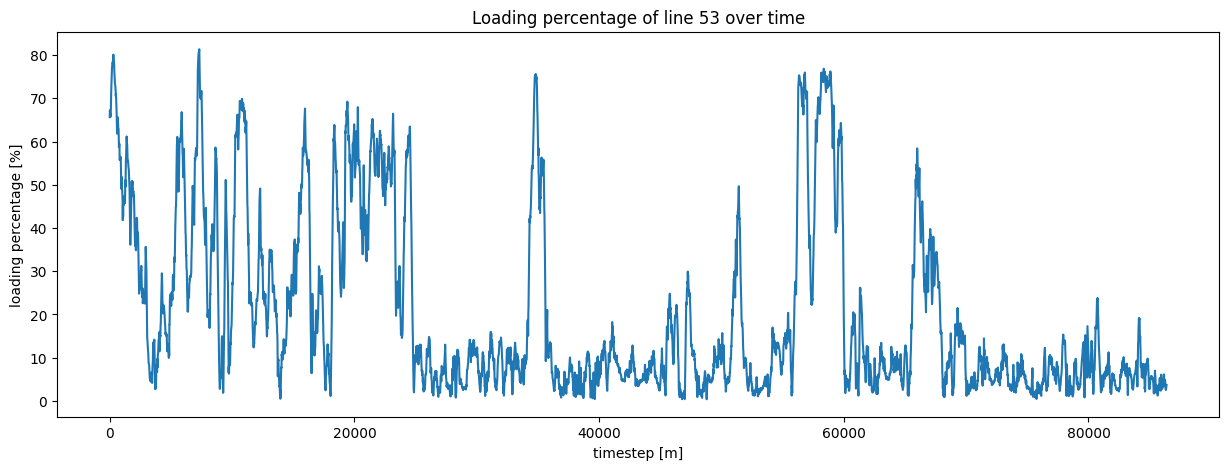

In [18]:
#Answer
#1)
x_axis = np.arange(len(y)) * 15
y_axis = y.values
plt.figure(figsize=(15,5))
plt.plot(x_axis, y_axis)
plt.xlabel("timestep [m]")
plt.ylabel("loading percentage [%]")
plt.title(f"Loading percentage of line {line_Y} over time")
plt.show()

# Creation of a regression plotting function for later results

In [19]:
def plot_regression_prediciton(y_pred, y_real, title):
    plt.figure(figsize=(20,5))
    plt.plot(y_real.index, y_pred, 'o')
    plt.plot(y_real, 'o')
    plt.xlabel('datapoints')
    plt.ylabel('line loading')
    plt.title(title)
    plt.legend(['Prediction', 'Actual'])
    plt.show()

# Data Preprocessing

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3065, shuffle=True)

Standardize generally means changing the values so that the distribution’s standard deviation equals one. Scaling is often implied.
StandardScaler standardizes a feature by subtracting the mean and then scaling to unit variance. Unit variance means dividing all the values by the standard deviation. StandardScaler results in a distribution with a standard deviation equal to 1. The variance is equal to 1 also, because variance = standard deviation squared. And 1 squared = 1.
StandardScaler makes the mean of the distribution 0. About 68% of the values will lie be between -1 and 1.

In [21]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Regression: 1.Linear Regression

LinearRegression fits a linear model with coefficients w = (w1, …, wp) to minimize the residual sum of squares between the observed targets in the dataset, and the targets predicted by the linear approximation.
More information in: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html


In [22]:
linear_reg = LinearRegression().fit(X_train, y_train)
#Score is R^2
linear_reg.score(X_train, y_train)

0.9182449417795946

In [23]:
y_pred_lr = linear_reg.predict(X_test)
#Score is R^2
linear_reg.score(X_test, y_test)

0.9201046476787456

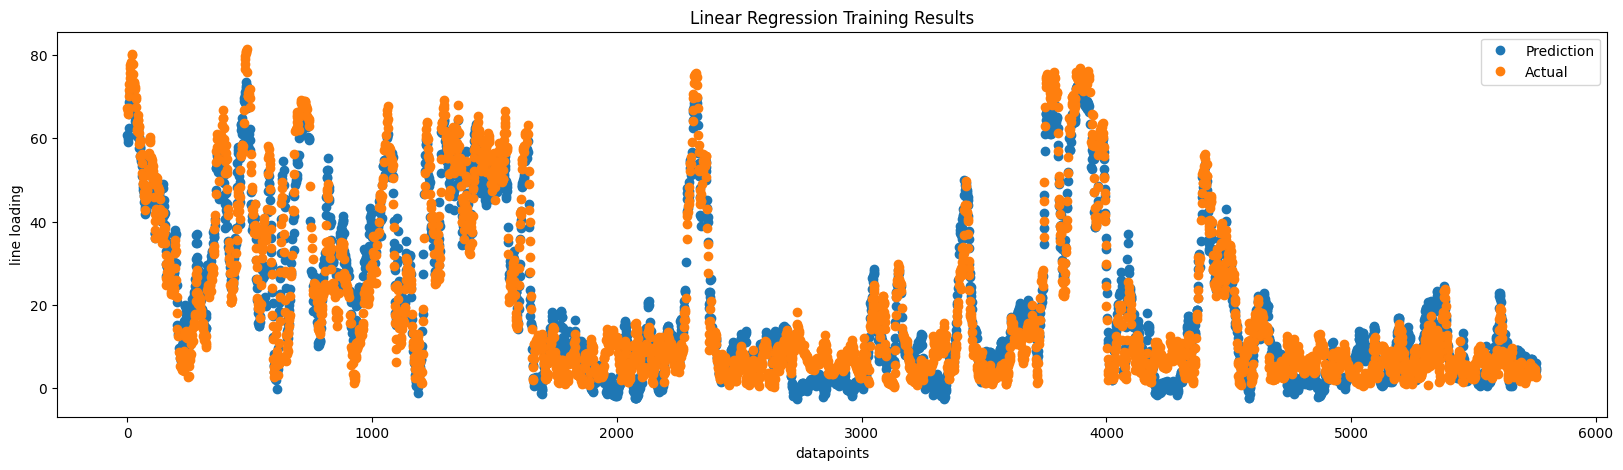

In [24]:
plot_regression_prediciton(linear_reg.predict(X_train), y_train, "Linear Regression Training Results")

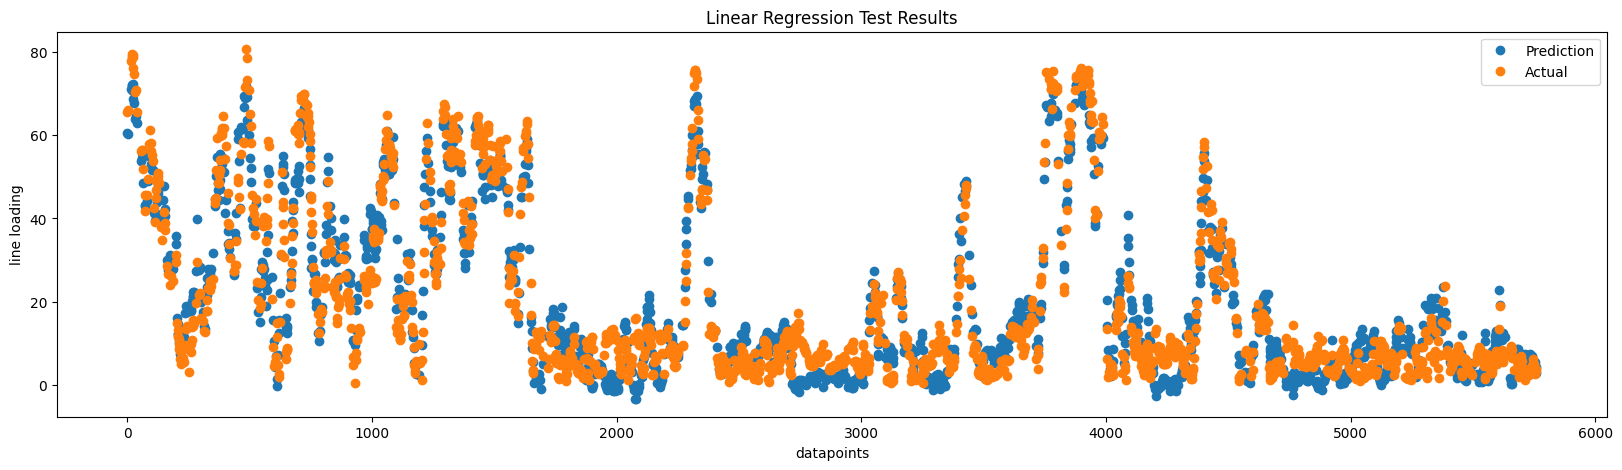

In [25]:
plot_regression_prediciton(y_pred_lr, y_test, "Linear Regression Test Results")

# Regression: 2. Support Vectors Regression (SVR)

More information at: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html#sklearn.svm.SVR

In [26]:
##Hyperparameters

#1. Specifies the kernel type to be used in the algorithm. It must be one of ‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’ or a
#callable. If none is given, ‘rbf’ will be used. If a callable is given it is used to precompute the kernel matrix.
kernel = 'rbf' #DO NOT CHANGE

#2. Degree of the polynomial kernel function (‘poly’). Ignored by all other kernels.
degree = 3 #DO NOT CHANGE

#3. Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’.
gamma = 'scale' # {‘scale’, ‘auto’} or float DO NOT CHANGE

#4. Independent term in kernel function. It is only significant in ‘poly’ and ‘sigmoid’.
coef0 = 0.0 #float DO NOT CHANGE

#5. Tolerance for stopping criterion.
tol = 1e-3 # DO NOT CHANGE

#6. Regularization parameter. The strength of the regularization is inversely proportional to C. Must be strictly positive.
#The penalty is a squared l2 penalty.
C = 1.

#7. Epsilon in the epsilon-SVR model. It specifies the epsilon-tube within which no penalty is associated in the training
#loss function with points predicted within a distance epsilon from the actual value.
epsilon = 0.1 # float DO NOT CHANGE

#8. Whether to use the shrinking heuristic
shrinking = True # bool DO NOT CHANGE

#9. Hard limit on iterations within solver, or -1 for no limit.
max_iter = 1000 # DO NOT CHANGE

As you can see, there are many hyperparameters which can be tuned to affect the performance of the model. In this task, you are asked only to fine tune the hyperparameter  <b>C</b> between values of </b>0.1 and 5</b>. Change the parameter value in 3 different models and document the performance differences between them.  

In [27]:
sv_reg = svm.SVR(kernel=kernel, C=C, epsilon=epsilon , gamma=gamma ,max_iter= max_iter).fit(X_train, y_train)
sv_reg.score(X_train, y_train)

/Users/timterhorst/Desktop/MSc. EPE/Q3/SET3065 - Intelligent Electrical Power Grids/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.9354411293994532

In [28]:
y_pred_svr = sv_reg.predict(X_test)
sv_reg.score(X_test, y_test)

0.9333190021574225

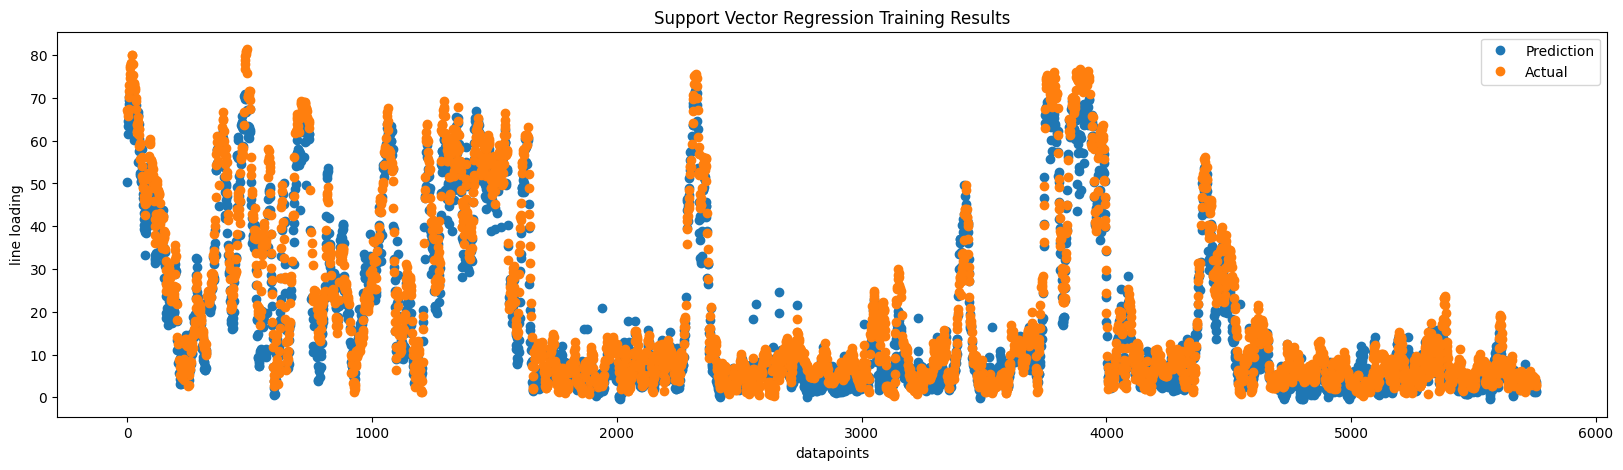

In [29]:
plot_regression_prediciton(sv_reg.predict(X_train), y_train, "Support Vector Regression Training Results")

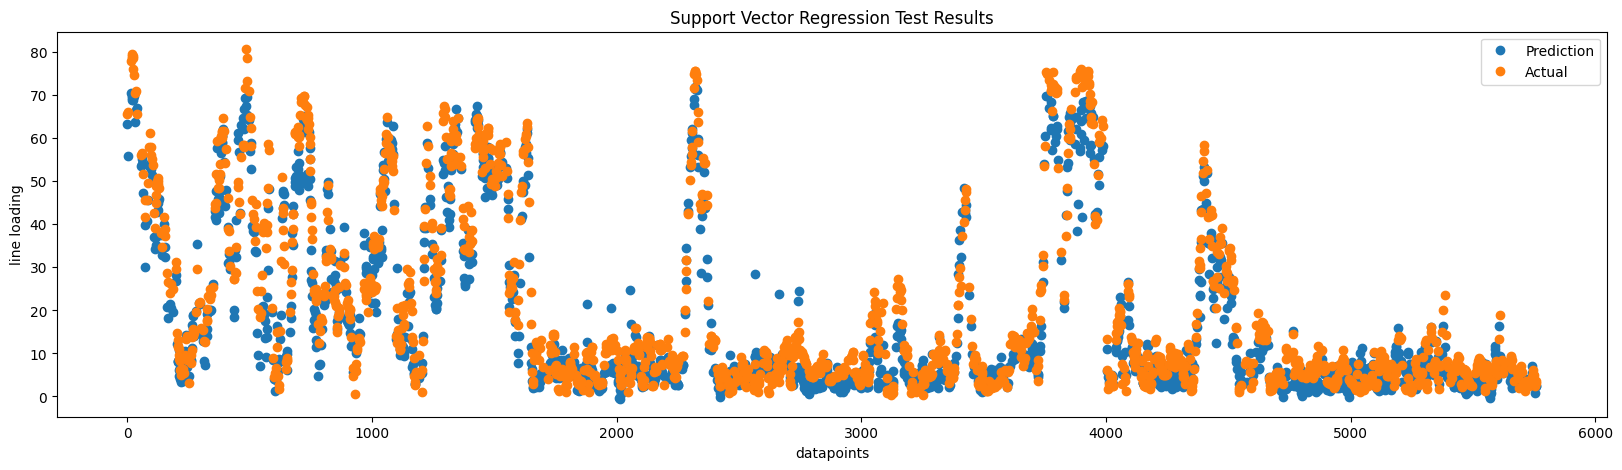

In [30]:
plot_regression_prediciton(y_pred_svr, y_test, "Support Vector Regression Test Results")

# Task 4: SVR Hyperparameter Tuning

1) Change the hyperparameter 'C' between values of 0.1 and 5 in order to improve the training error. Report the resulted training and test errors for 3 different combinations. Based on your results, which model would you choose and why?

In [31]:
#Answers
C_values = [0.1, 1, 5]
labels = ['A', 'B', 'C']
train_scores = []
test_scores = []

for label, C_val in zip(labels, C_values):
    svr = svm.SVR(kernel='rbf', C=C_val, epsilon=0.1, gamma='scale', max_iter=1000).fit(X_train, y_train)
    train_r2 = svr.score(X_train, y_train)
    test_r2 = svr.score(X_test, y_test)
    train_scores.append(train_r2)
    test_scores.append(test_r2)
    print(f"{label}. For the hyperparameter C = {C_val}, the resulted training and test R² scores are {train_r2:.4f} and {test_r2:.4f}")

print(f"\nMy chosen hyperparameter C would be 5, because it achieves the highest test R² score ({test_scores[2]:.4f}), indicating the best generalization performance among the three values tested. Note that this selection is based directly on test set performance rather than a separate validation set.")


/Users/timterhorst/Desktop/MSc. EPE/Q3/SET3065 - Intelligent Electrical Power Grids/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


A. For the hyperparameter C = 0.1, the resulted training and test R² scores are 0.6511 and 0.6473


/Users/timterhorst/Desktop/MSc. EPE/Q3/SET3065 - Intelligent Electrical Power Grids/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


B. For the hyperparameter C = 1, the resulted training and test R² scores are 0.9354 and 0.9333


/Users/timterhorst/Desktop/MSc. EPE/Q3/SET3065 - Intelligent Electrical Power Grids/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


C. For the hyperparameter C = 5, the resulted training and test R² scores are 0.9575 and 0.9557

My chosen hyperparameter C would be 5, because it achieves the highest test R² score (0.9557), indicating the best generalization performance among the three values tested. Note that this selection is based directly on test set performance rather than a separate validation set.


# Regression: 3. Decision Tree Regression

In [32]:
##Hyperparameters

#.0 Random State is used to repeat same results whenever the model is run
random_state = 3065 #DO NOT CHANGE

#1. The function to measure the quality of a split. Supported criteria are “squared_error” for the mean squared error,
#which is equal to variance reduction as feature selection criterion and minimizes the L2 loss using the mean of each terminal
#node, “friedman_mse”, which uses mean squared error with Friedman’s improvement score for potential splits,
#“absolute_error” for the mean absolute error, which minimizes the L1 loss using the median of each terminal node,
#and “poisson” which uses reduction in Poisson deviance to find splits.
criterion = "squared_error" #{“squared_error”, “friedman_mse”, “absolute_error”, “poisson”}

#2. The strategy used to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.
splitter = 'best' #{“best”, “random”}

#3. The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
max_depth = None # int

#4. The minimum number of samples required to split an internal node:
min_samples_split = 3 # int or float

#5. The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves
#at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.
min_samples_leaf = 1 # int or float

#6. The minimum weighted fraction of the sum total of weights (of all the input samples) required to be at a leaf node.
#Samples have equal weight when sample_weight is not provided.
min_weight_fraction_leaf = 0. # float

#7. The number of features to consider when looking for the best split:
max_features = 10 # int or float or {"auto, "sqrt", "log2"}, None => n_features

#8. Grow a tree with max_leaf_nodes in best-first fashion. Best nodes are defined as relative reduction in impurity. If None then unlimited number of leaf nodes.
max_leaf_nodes = None # int

#9. A node will be split if this split induces a decrease of the impurity greater than or equal to this value.
min_impurity_decrease = 0.0 # float

#10. Complexity parameter used for Minimal Cost-Complexity Pruning. The subtree with the largest cost complexity that is smaller than ccp_alpha will be chosen.
#By default, no pruning is performed.
ccp_alpha = 0.0 # non negative float


As you can see, there are many hyperparameters which can be tuned to affect the performance of the model. In this task, you are asked only to fine tune the hyperparameter  <b>min_samples_split</b> between values of </b>2 and 50</b>. Change the parameter value in 3 different models and document the performance differences between them.  

In [33]:
DT_reg = DecisionTreeRegressor(random_state=random_state, splitter=splitter, max_depth=max_depth, min_samples_split=min_samples_split,
                               min_samples_leaf=min_samples_leaf, min_weight_fraction_leaf=min_weight_fraction_leaf, max_features=max_features,
                               max_leaf_nodes=max_leaf_nodes, min_impurity_decrease=min_impurity_decrease, ccp_alpha=ccp_alpha)
DT_reg.fit(X_train,y_train)
DT_reg.score(X_train, y_train)

0.9995233187153516

In [34]:
y_pred_dtr = DT_reg.predict(X_test)
DT_reg.score(X_test, y_test)

0.9590347514473941

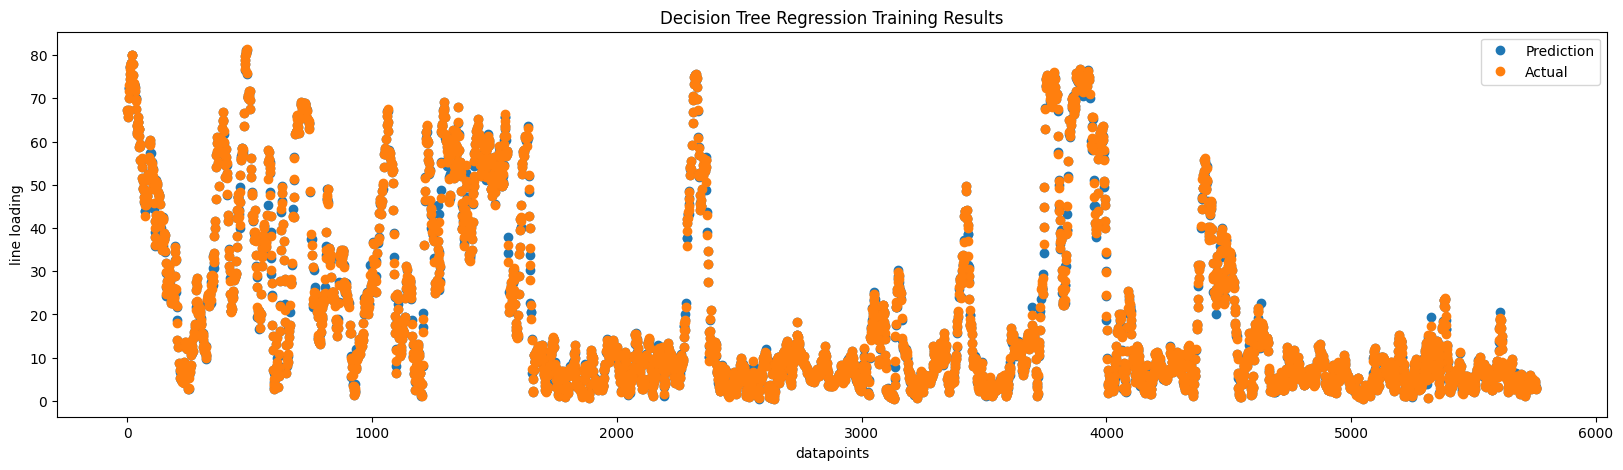

In [35]:
plot_regression_prediciton(DT_reg.predict(X_train), y_train, "Decision Tree Regression Training Results")

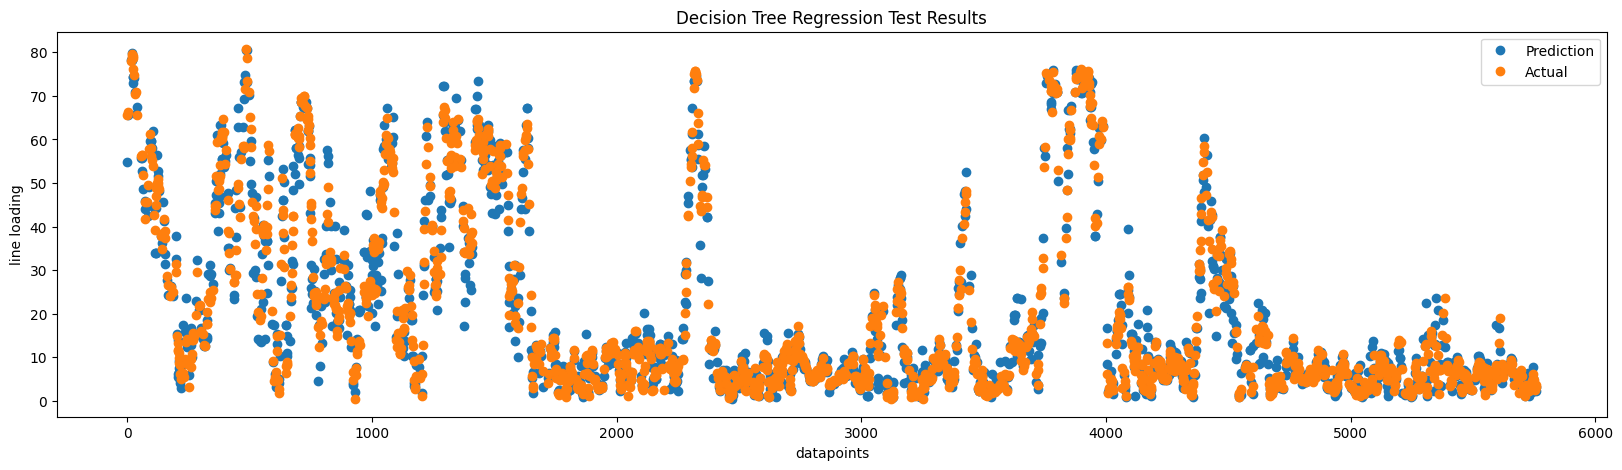

In [36]:
plot_regression_prediciton(y_pred_dtr, y_test, "Decision Tree Regression Test Results")

# Task 5: Decision Tree Regressor Hyperparameter Tuning

1) Change the hyperparameter 'min_samples_split' in order to improve the current model (if you are not able to improve the model explain why). Report the resulted training and test errors for 3 different combinations between 2 and 50. Based on your results, which model would you choose and why?

In [37]:
#Answers
mss_values = [2, 10, 50]
labels = ['A', 'B', 'C']
train_scores_dt = []
test_scores_dt = []

for label, mss in zip(labels, mss_values):
    dt = DecisionTreeRegressor(
        random_state=3065, splitter='best', max_depth=None, min_samples_split=mss,
        min_samples_leaf=1, min_weight_fraction_leaf=0., max_features=10,
        max_leaf_nodes=None, min_impurity_decrease=0., ccp_alpha=0.
    ).fit(X_train, y_train)
    train_r2 = dt.score(X_train, y_train)
    test_r2 = dt.score(X_test, y_test)
    train_scores_dt.append(train_r2)
    test_scores_dt.append(test_r2)
    print(f"{label}. For the hyperparameter 'min_samples_split' = {mss}, the resulted training and test R² scores are {train_r2:.4f} and {test_r2:.4f}")

print(f"\nMy chosen hyperparameter 'min_samples_split' would be 50, because it achieves the highest test R² score ({test_scores_dt[2]:.4f}). A higher min_samples_split produces a shallower tree, which reduces overfitting and improves generalization to unseen data.")

A. For the hyperparameter 'min_samples_split' = 2, the resulted training and test R² scores are 1.0000 and 0.9597
B. For the hyperparameter 'min_samples_split' = 10, the resulted training and test R² scores are 0.9932 and 0.9622
C. For the hyperparameter 'min_samples_split' = 50, the resulted training and test R² scores are 0.9782 and 0.9664

My chosen hyperparameter 'min_samples_split' would be 50, because it achieves the highest test R² score (0.9664). A higher min_samples_split produces a shallower tree, which reduces overfitting and improves generalization to unseen data.


# Classification Label Set Creation

The line in the context of these lecture will be considered as within dangerous limits when it's
loading percentage is equal or higher than 60%. Hence, the target label of each datapoint needs to be determined. Loading percentages higher than 60% will be labeled as 1, while the rest of the line loading percentages will be labeled as 0.

# Task 6: Creation of Classification Label Set

1) Using the y_train set, create the classification labels vector y_train_class with values 0 and 1 as explained above. Print the ratio of training set safe datapoints with respect to all the training set data points <br>
2) Using the y_test set, create the classification labels vector y_test_class with values 0 and 1 as explained above. Print the ratio of test set safe datapoints with respect to all the test set data point <br>


In [38]:
#Answers
limit =60.


y_train_class = (y_train >= limit).astype(int)
y_test_class = (y_test >= limit).astype(int)
safe_train_ratio = 100. * float(sum(y_train_class))/len(y_train_class)
safe_test_ratio = 100. * float(sum(y_test_class))/len(y_test_class)

print(f"Out of {len(y_train_class)} Training data, the {safe_train_ratio} % are representing 'safe' line percentage")
print(f"Out of {len(y_test_class)} Test data, the {safe_test_ratio} % are representing 'safe' line percentage")

Out of 4032 Training data, the 7.266865079365079 % are representing 'safe' line percentage
Out of 1728 Test data, the 8.449074074074074 % are representing 'safe' line percentage


# Classification Printing Function Creation

In [39]:
def plot_classification_prediction(y_real, y_pred_class, y_real_class, title):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(30, 5))
    axes[0].scatter(y_real.index, y_real, c=y_pred_class, cmap=clrs.ListedColormap(['blue', 'red']))
    axes[1].scatter(y_real.index, y_real, c=y_real_class, cmap=clrs.ListedColormap(['blue', 'red']))
    axes[0].set_xlabel('datapoints')
    axes[0].set_ylabel('line loading')
    axes[1].set_xlabel('datapoints')
    axes[1].set_ylabel('line loading')
    axes[0].title.set_text('Predicted Classes')
    axes[1].title.set_text('Actual Classes')
    fig.suptitle(title, fontsize=16)
    plt.show()


def plot_confusion_matrix_academic(estimator, X, y, title, display_labels=None):
    """Plot a confusion matrix with clear labels and a sequential colormap (academic style)."""
    if display_labels is None:
        display_labels = ["Safe (0)", "Dangerous (1)"]
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay.from_estimator(
        estimator, X, y,
        display_labels=display_labels,
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=True,
    )
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=16)
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

# Classification 1: Linear Classification - Logistic Regression Classifier

This class implements regularized logistic regression using the ‘liblinear’ library, ‘newton-cg’, ‘sag’, ‘saga’ and ‘lbfgs’ solvers. Note that regularization is applied by default. It can handle both dense and sparse input. Use C-ordered arrays or CSR matrices containing 64-bit floats for optimal performance; any other input format will be converted (and copied).
More information at: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression

In [40]:
# Hyperparameters

#.0 Random State is used to repeat same results whenever the model is run
random_state = 3065 #DO NOT CHANGE

#1. Specify the norm of the penalty:
penalty = 'l2' #'l1', 'l2', ‘elasticnet’, ‘none’

#2. Dual or primal formulation. Dual formulation is only implemented for l2 penalty with liblinear solver.
#Prefer dual=False when n_samples > n_features.
dual = False # Do not change in our case given the above inequality

#3. Tolerance for stopping criterion.
tol = 1e-3 #float

#4. Inverse of regularization strength; must be a positive float.
#Like in support vector machines, smaller values specify stronger regularization.
C = 1.  #float

#5. Specifies if a constant (a.k.a. bias or intercept) should be added to the decision function.
fit_intercept = True #bool

#6. Useful only when the solver ‘liblinear’ is used and self.fit_intercept is set to True. In this case,
#x becomes [x, self.intercept_scaling], i.e. a “synthetic” feature with constant value equal to intercept_scaling
#is appended to the instance vector. The intercept becomes intercept_scaling * synthetic_feature_weight.
intercept_scaling = 1. #float

#7. Weights associated with classes in the form {class_label: weight}. If not given, all classes are supposed to have weight one.
#The “balanced” mode uses the values of y to automatically adjust weights inversely proportional to class frequencies
#in the input data as n_samples / (n_classes * np.bincount(y)).
class_weight = None # dict or 'balanced'


In [41]:
lr_class = LogisticRegression(random_state=random_state, penalty=penalty, dual=dual, tol=tol,
                              C=C, fit_intercept=fit_intercept, intercept_scaling=intercept_scaling,
                              class_weight=class_weight)
lr_class.fit(X_train, y_train_class)

#Return the mean accuracy on the given test data and labels
lr_class.score(X_train, y_train_class)

/Users/timterhorst/Desktop/MSc. EPE/Q3/SET3065 - Intelligent Electrical Power Grids/.conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


0.9836309523809523

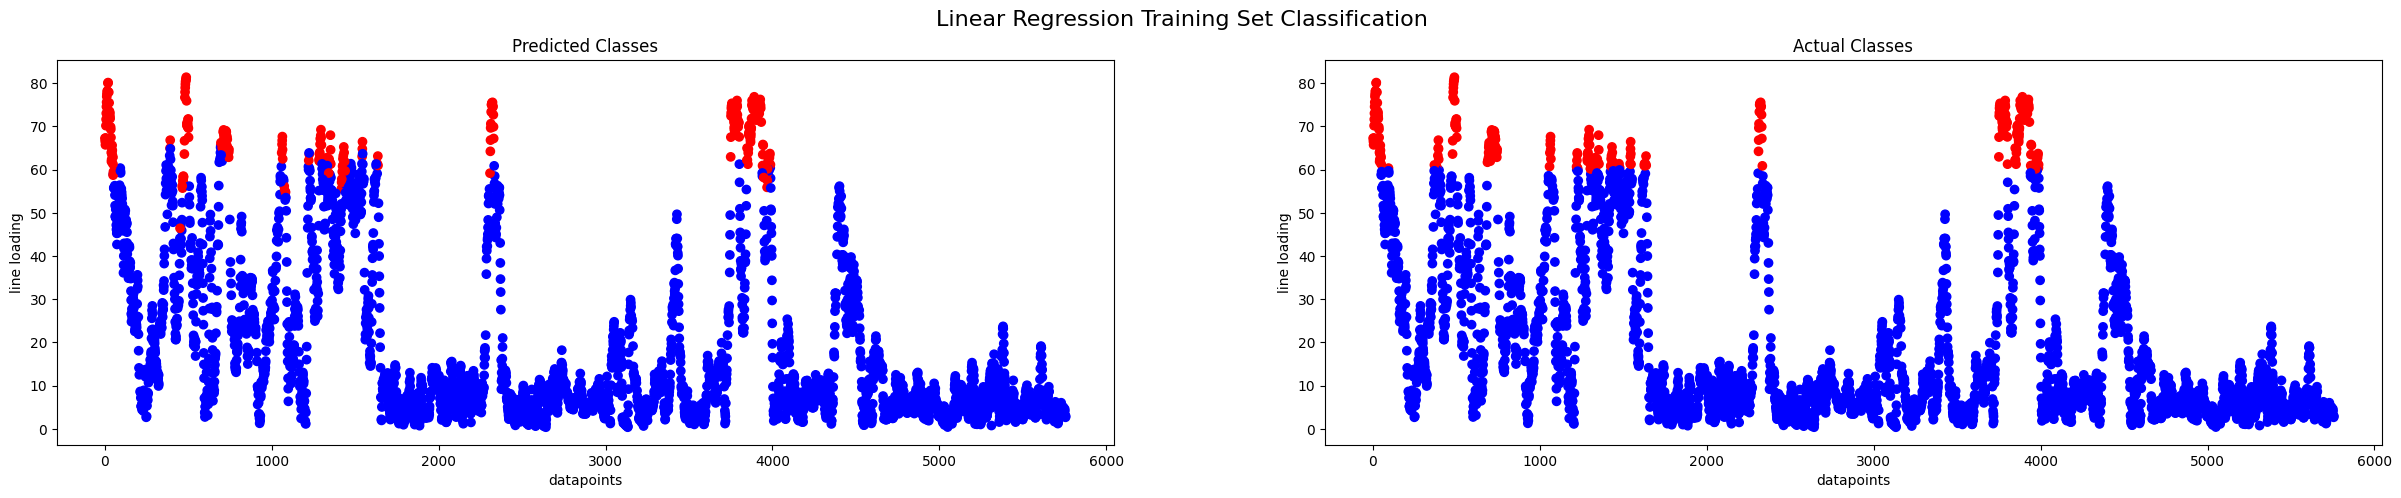

In [42]:
plot_classification_prediction(y_train, lr_class.predict(X_train), y_train_class, "Linear Regression Training Set Classification")

The left figure plotted above illustrates the datapoints which were predicted as safe in blue, and the ones which were predicted as dangerous in red. The right figure illustrates the data point which were actually safe in blue, and the ones which were actually dangerous in red. Comparing those two graphs it is obvious that the majority of the datapoints is correctly classified but there are still some missclassification instances.

To help us visualize the amount of mistclassified data points, but also to have more insights on the performance of the model with respect to each class, the confusion matrix is created below. This matrix, shows information such as how many of the actually safe (class 0 ) datapoints were identified by the model, and how many were not. Similarly, it also shows how many of the actually dangerous datapoints were identified and how many were not. Those values can be used to obtain metrics such as Precision, Recall, F1 score and Accuracy.

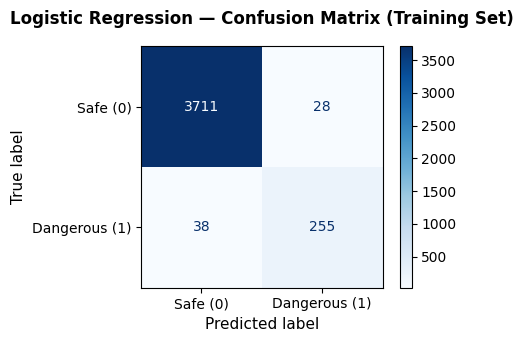

In [43]:
plot_confusion_matrix_academic(
    lr_class, X_train, y_train_class,
    title="Logistic Regression — Confusion Matrix (Training Set)"
)

Although the previous graphs can showcase how the model performs on the training data, that performance evaluation might not be a good representation on how the model would perform to new, unseen data. Therefore, we also create the same figures for the test data, which represent a more accurate model performance to new data.

In [44]:
y_pred_lrc = lr_class.predict(X_test)
lr_class.score(X_test, y_test_class)

0.9722222222222222

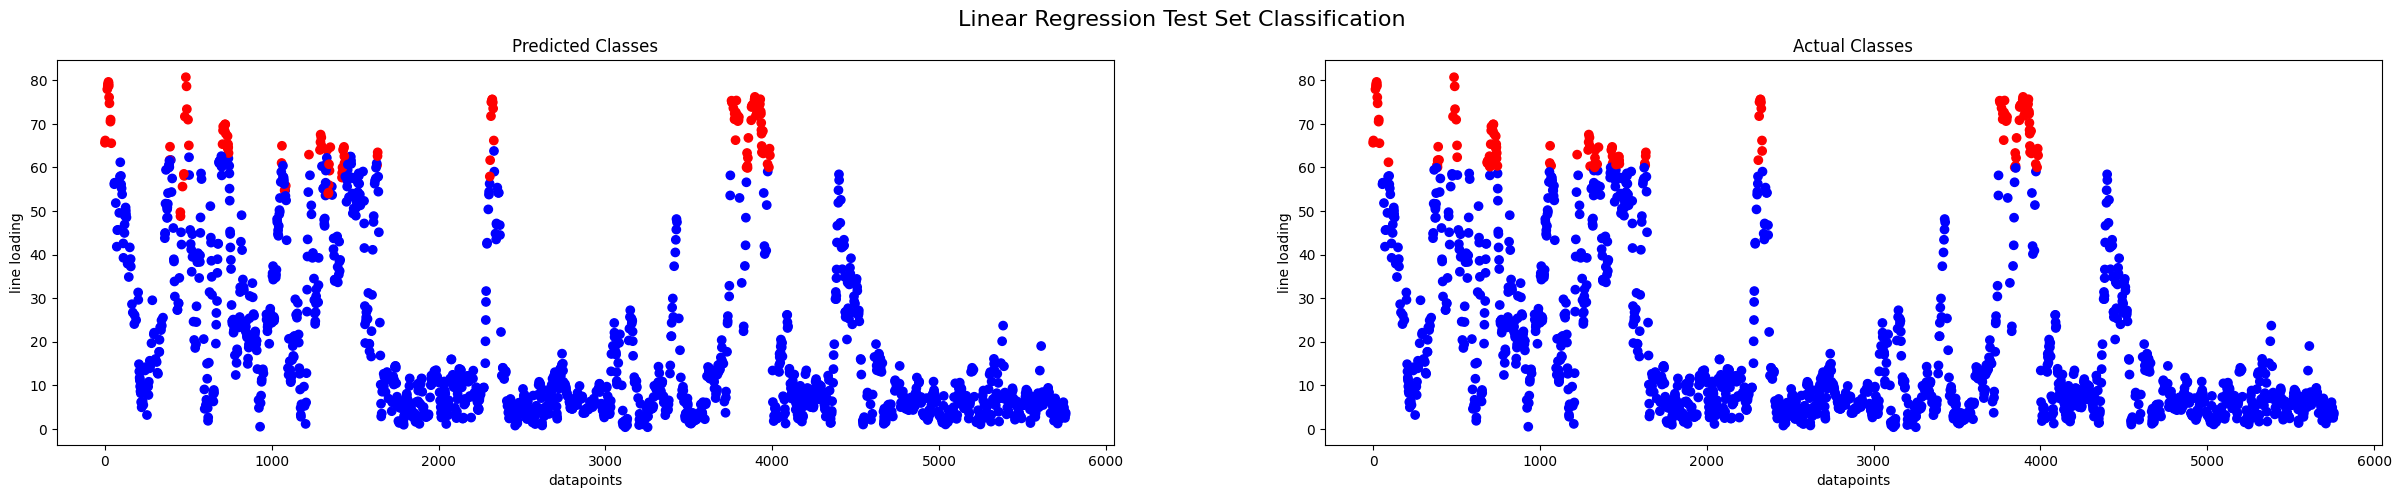

In [45]:
plot_classification_prediction(y_test, y_pred_lrc, y_test_class, "Linear Regression Test Set Classification")

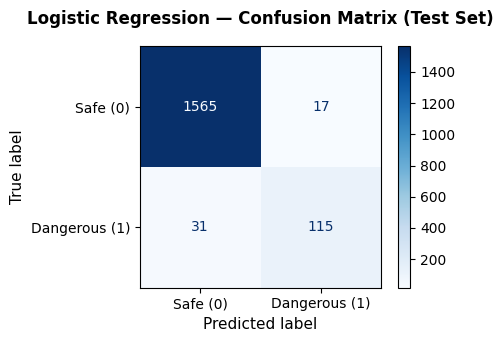

In [46]:
plot_confusion_matrix_academic(
    lr_class, X_test, y_test_class,
    title="Logistic Regression — Confusion Matrix (Test Set)"
)

# Task 7: Creation of SVM Classification Model

1) Create an SVM classifier using scikit learn (Hint: Copy Implementation of Classifier 1 and then visit https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC to change model function, and hyperparameters) <br>
2) Train the SVM classifier (Hint: Similar to Classifier 1) <br>
3) Report training & test scores <br>
4) Plot the classification results for the test set using the plot_classification_prediction() function <br>
5) Plot the confusion matrix for the test set <br>

SVM Classifier Training Accuracy: 0.9876
SVM Classifier Test Accuracy: 0.9734


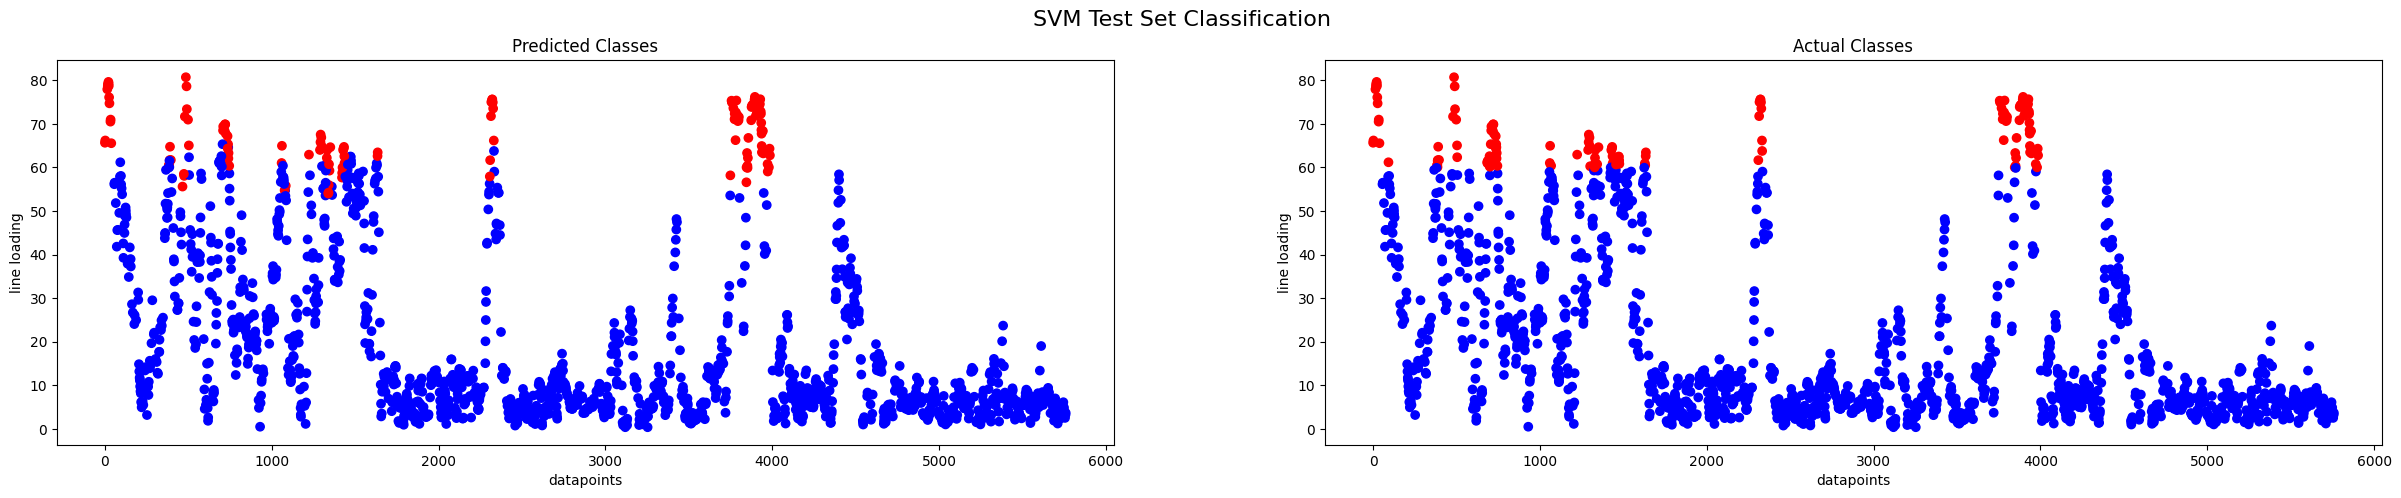

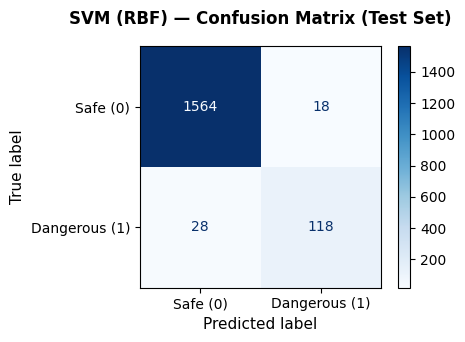

In [47]:
# 1) Create SVM classifier
svm_class = svm.SVC(kernel='rbf', C=5.0, gamma='scale', degree=3, coef0=0.0,
                     tol=1e-3, shrinking=True, class_weight=None, random_state=3065)

# 2) Train the SVM classifier
svm_class.fit(X_train, y_train_class)

# 3) Report training & test scores
train_score_svm = svm_class.score(X_train, y_train_class)
test_score_svm = svm_class.score(X_test, y_test_class)
print(f"SVM Classifier Training Accuracy: {train_score_svm:.4f}")
print(f"SVM Classifier Test Accuracy: {test_score_svm:.4f}")

# 4) Plot classification results for the test set
y_pred_svm = svm_class.predict(X_test)
plot_classification_prediction(y_test, y_pred_svm, y_test_class, "SVM Test Set Classification")

# 5) Confusion matrix for the test set
plot_confusion_matrix_academic(
    svm_class, X_test, y_test_class,
    title="SVM (RBF) — Confusion Matrix (Test Set)"
)

# (Optional) Task 8: Creation of Decision Tree Classification Model


1) Develop a Decision Tree classifier using scikit learn

2) Train the Decision Tree classifier (Hint: Similar to Classifier 1)

3) Report training & test scores

4) Plot the classification results for the test set using the plot classification prediction() function

5) Plot the confusion matrix for the test set

Decision Tree Classifier Training Accuracy: 0.9859
Decision Tree Classifier Test Accuracy: 0.9682


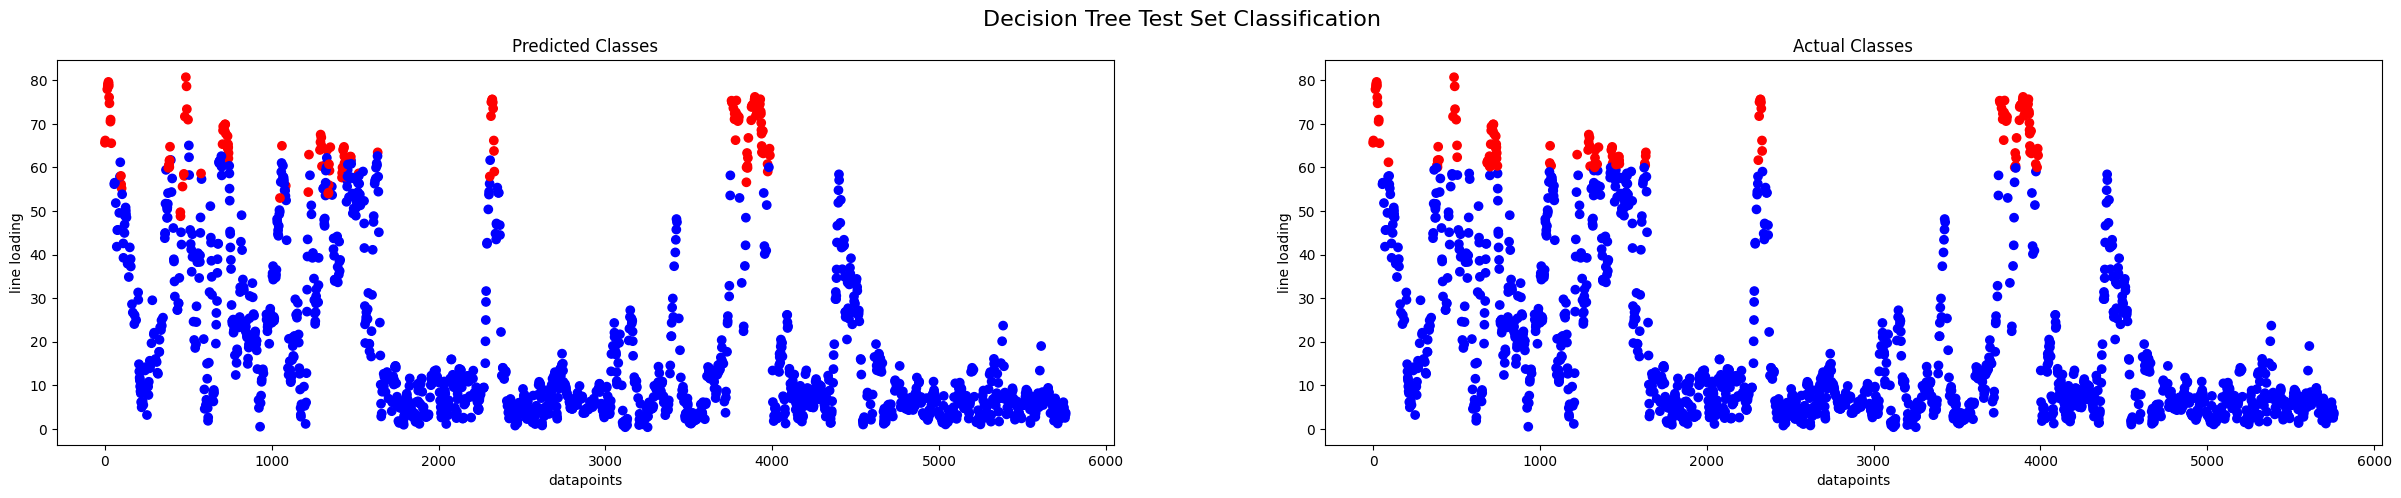

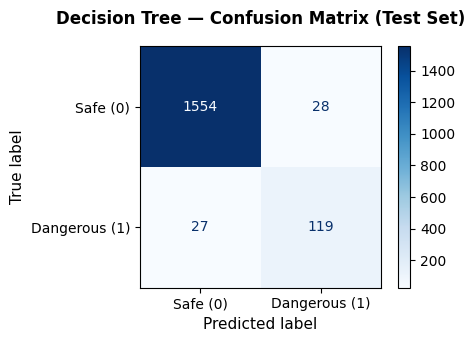

In [48]:
# 1) Create Decision Tree classifier
dt_class = DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=None,
                                   min_samples_split=50, min_samples_leaf=1,
                                   max_features=10, random_state=3065)

# 2) Train the Decision Tree classifier
dt_class.fit(X_train, y_train_class)

# 3) Report training & test scores
train_score_dt = dt_class.score(X_train, y_train_class)
test_score_dt = dt_class.score(X_test, y_test_class)
print(f"Decision Tree Classifier Training Accuracy: {train_score_dt:.4f}")
print(f"Decision Tree Classifier Test Accuracy: {test_score_dt:.4f}")

# 4) Plot classification results for the test set
y_pred_dt = dt_class.predict(X_test)
plot_classification_prediction(y_test, y_pred_dt, y_test_class, "Decision Tree Test Set Classification")

# 5) Confusion matrix for the test set
plot_confusion_matrix_academic(
    dt_class, X_test, y_test_class,
    title="Decision Tree — Confusion Matrix (Test Set)"
)

/Users/timterhorst/Desktop/MSc. EPE/Q3/SET3065 - Intelligent Electrical Power Grids/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


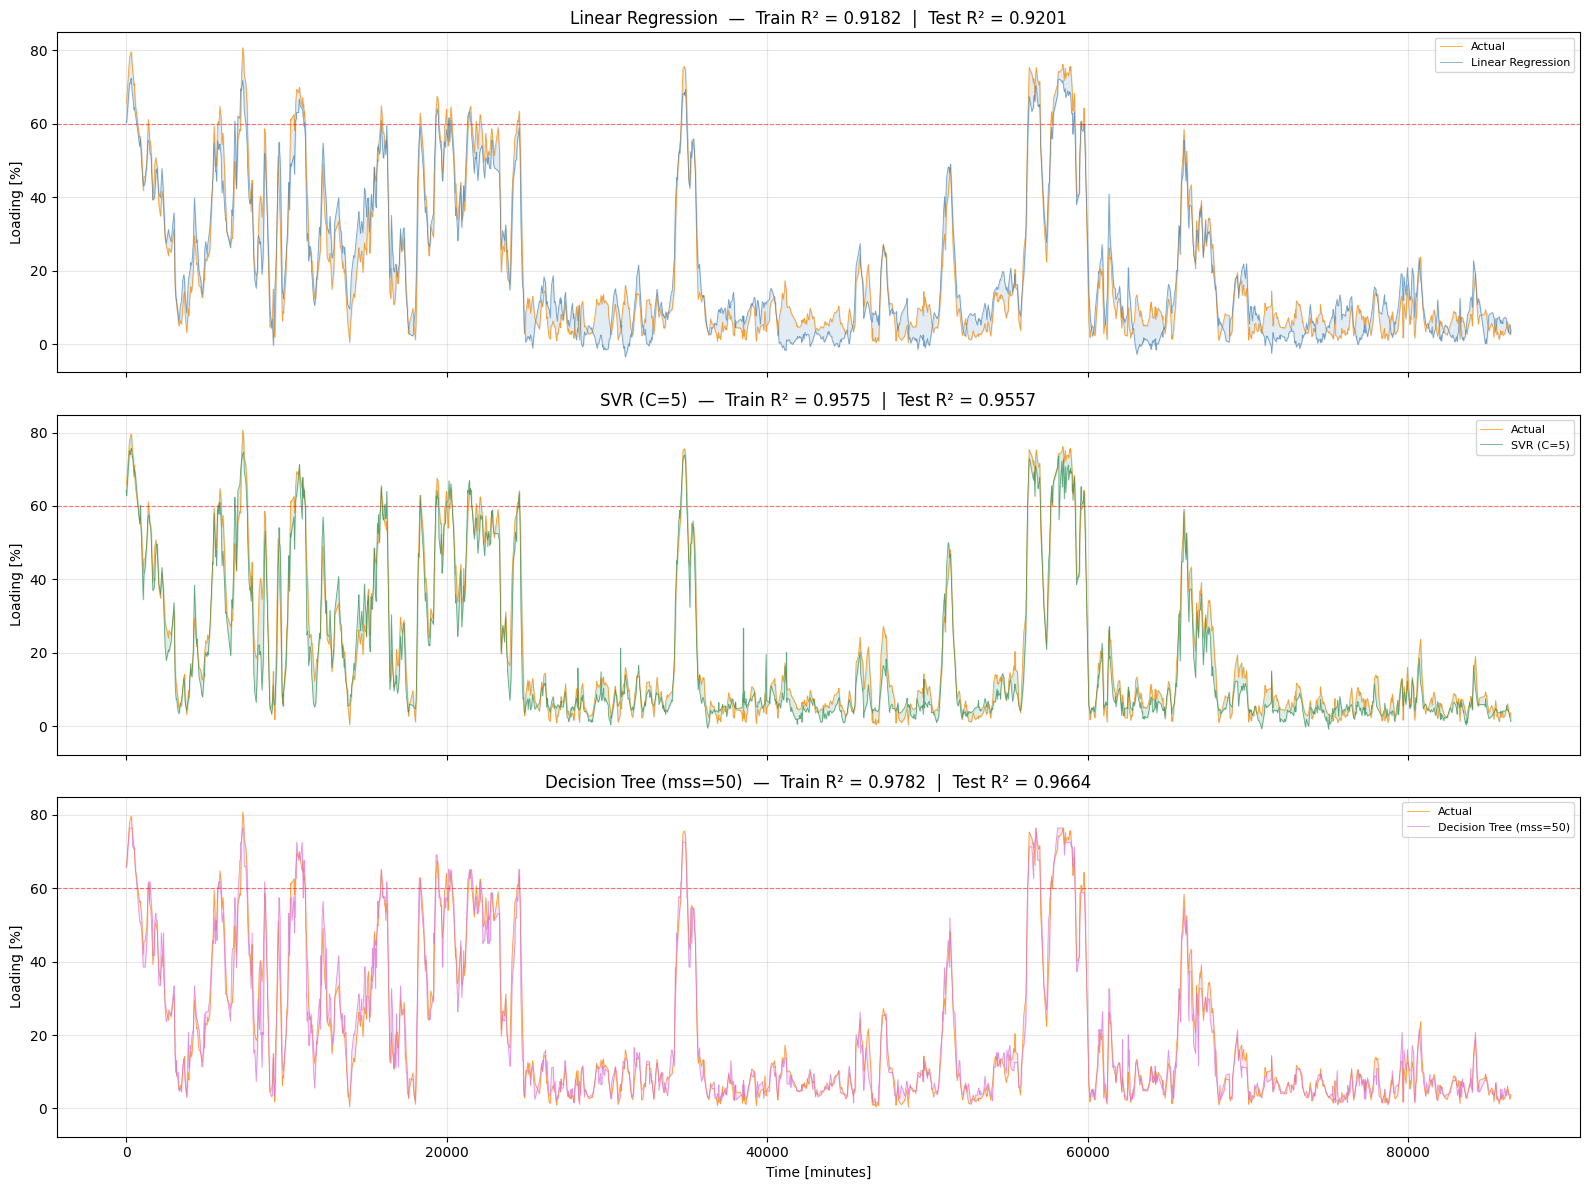

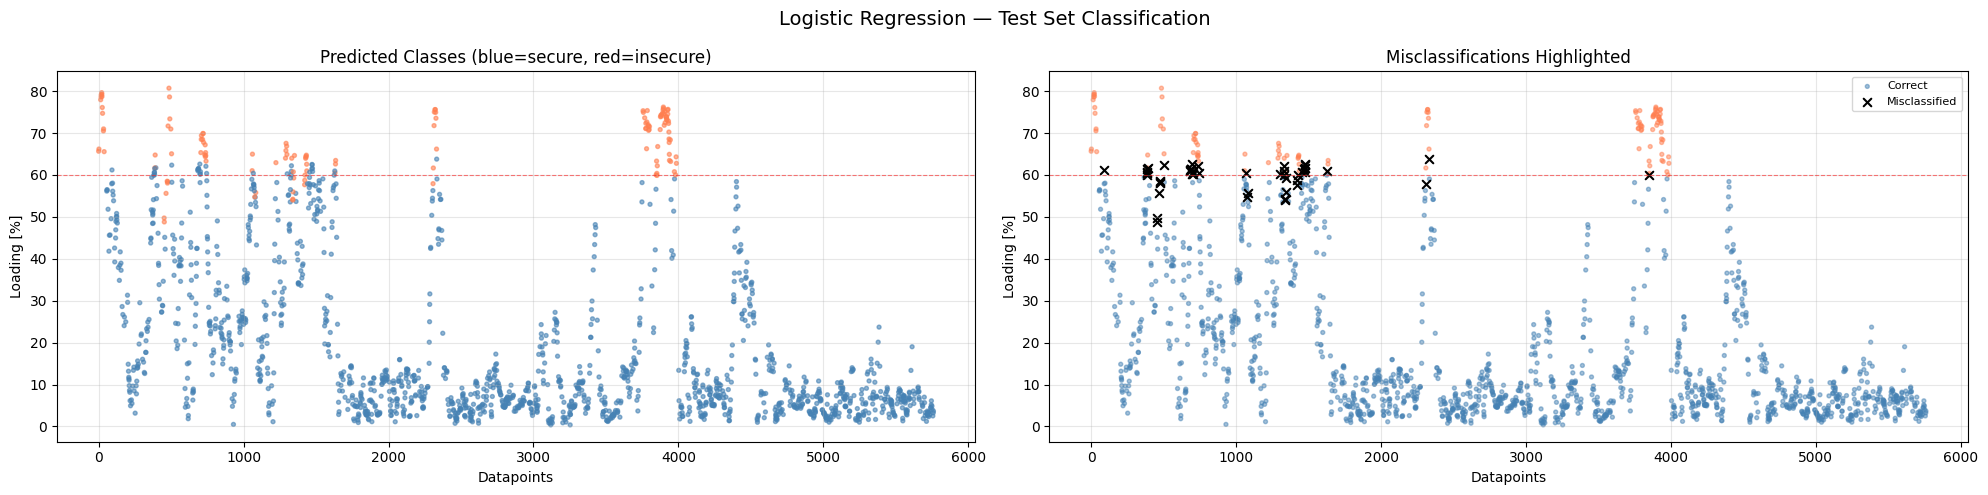

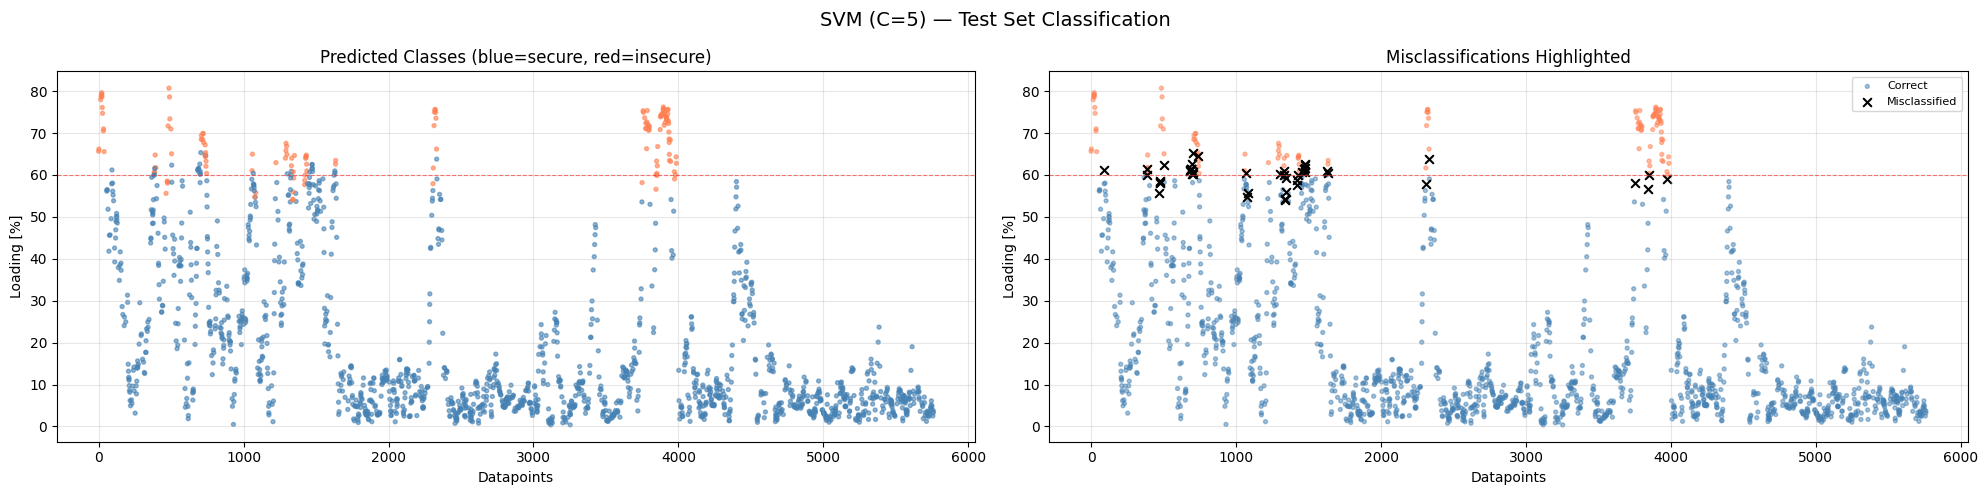

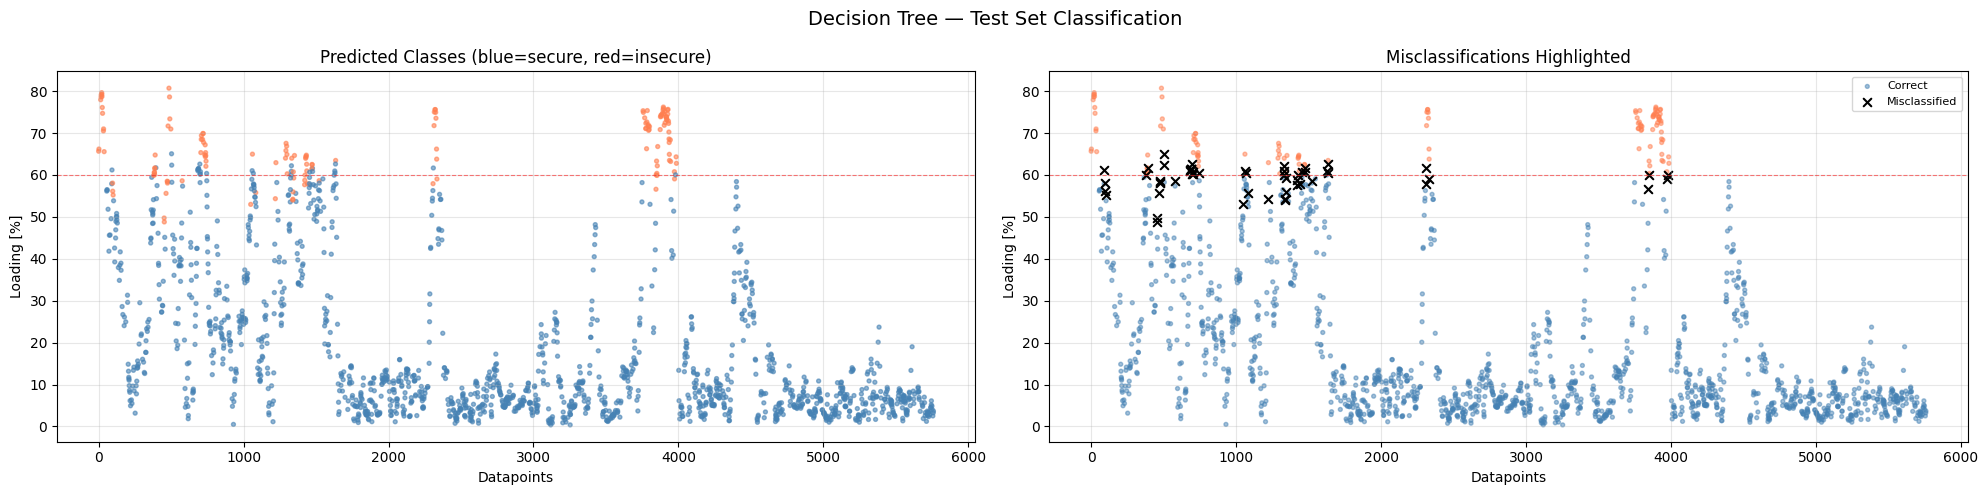

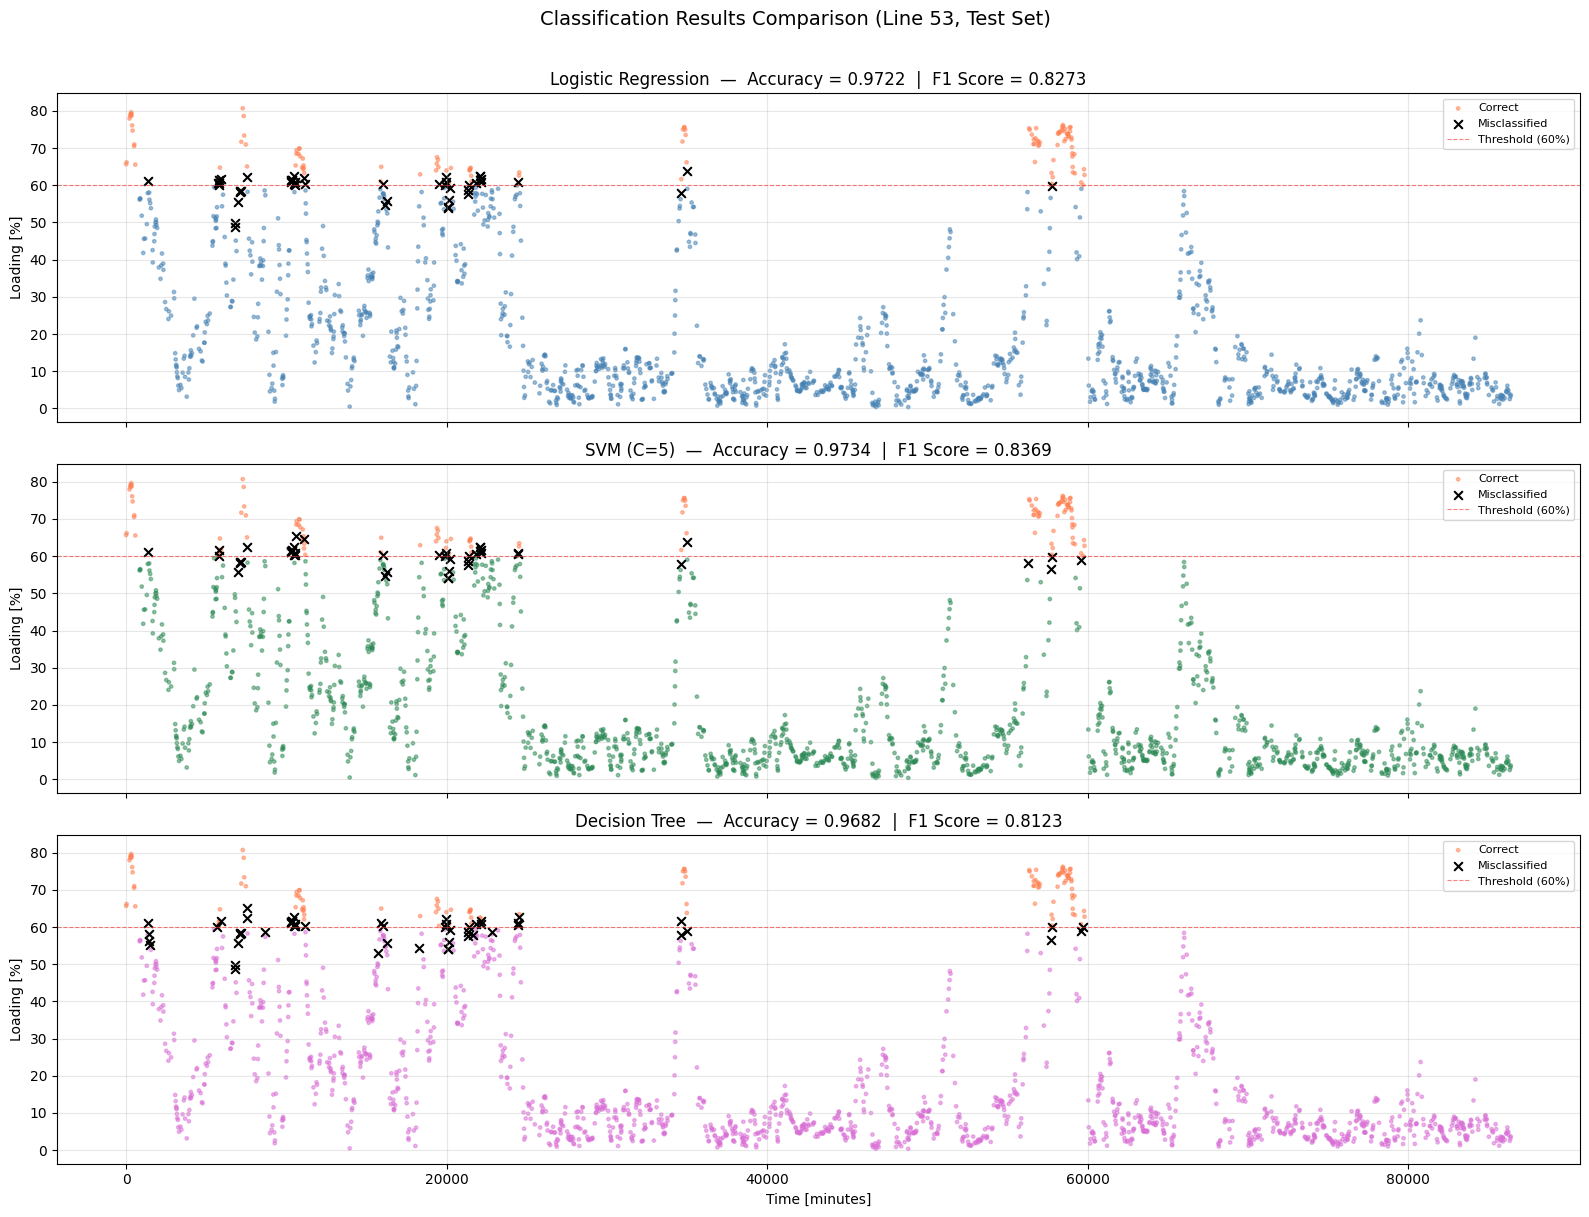

In [57]:
# --- Improved Regression Visualization: one subplot per regressor ---

sorted_idx = np.argsort(y_test.index)
test_minutes_sorted = y_test.index.values[sorted_idx] * 15
y_actual_sorted = y_test.values[sorted_idx]

svr_best = svm.SVR(kernel='rbf', C=5, epsilon=0.1, gamma='scale', max_iter=1000).fit(X_train, y_train)
dt_best = DecisionTreeRegressor(
    random_state=3065, splitter='best', max_depth=None, min_samples_split=50,
    min_samples_leaf=1, min_weight_fraction_leaf=0., max_features=10,
    max_leaf_nodes=None, min_impurity_decrease=0., ccp_alpha=0.
).fit(X_train, y_train)

reg_models = {
    'Linear Regression': linear_reg,
    'SVR (C=5)':         svr_best,
    'Decision Tree (mss=50)': dt_best,
}
reg_preds = {
    'Linear Regression': y_pred_lr,
    'SVR (C=5)':         svr_best.predict(X_test),
    'Decision Tree (mss=50)': dt_best.predict(X_test),
}
reg_colors = ['steelblue', 'seagreen', 'orchid']

fig, axes = plt.subplots(len(reg_preds), 1, figsize=(16, 4 * len(reg_preds)), sharex=True, sharey=True)

for ax, (name, preds), color in zip(axes, reg_preds.items(), reg_colors):
    preds_sorted = preds[sorted_idx]
    ax.plot(test_minutes_sorted, y_actual_sorted, color='darkorange', linewidth=0.6, alpha=0.8, label='Actual')
    ax.plot(test_minutes_sorted, preds_sorted, color=color, linewidth=0.6, alpha=0.7, label=name)
    ax.fill_between(test_minutes_sorted, y_actual_sorted, preds_sorted, color=color, alpha=0.15)
    ax.axhline(y=60, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    model = reg_models[name]
    r2_train = model.score(X_train, y_train)
    r2_test = model.score(X_test, y_test)
    ax.set_ylabel('Loading [%]')
    ax.set_title(f'{name}  —  Train R² = {r2_train:.4f}  |  Test R² = {r2_test:.4f}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time [minutes]')
# fig.suptitle(f'Regression Predictions vs Actual Loading (Line {line_Y}, Test Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# --- Improved Classification Visualization ---

def plot_classification_improved(y_real, y_pred_class, y_real_class, title):
    """Side-by-side: original view + misclassification-highlighted view."""
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))

    # Left: original style (predicted classes)
    axes[0].scatter(y_real.index, y_real, c=y_pred_class,
                    cmap=clrs.ListedColormap(['steelblue', 'coral']), s=8, alpha=0.6)
    axes[0].axhline(y=60, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[0].set_xlabel('Datapoints')
    axes[0].set_ylabel('Loading [%]')
    axes[0].set_title('Predicted Classes (blue=secure, red=insecure)')
    axes[0].grid(True, alpha=0.3)

    # Right: misclassification highlight
    correct = y_pred_class == y_real_class
    wrong = ~correct
    axes[1].scatter(y_real.index[correct], y_real.values[correct],
                    c=y_pred_class[correct], cmap=clrs.ListedColormap(['steelblue', 'coral']),
                    s=8, alpha=0.5, vmin=0, vmax=1, label='Correct')
    axes[1].scatter(y_real.index[wrong], y_real.values[wrong],
                    marker='x', c='black', s=30, linewidths=1.5, label='Misclassified')
    axes[1].axhline(y=60, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[1].set_xlabel('Datapoints')
    axes[1].set_ylabel('Loading [%]')
    axes[1].set_title('Misclassifications Highlighted')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot for all classifiers (individual)
plot_classification_improved(y_test, y_pred_lrc, y_test_class.values, 'Logistic Regression — Test Set Classification')
plot_classification_improved(y_test, y_pred_svm, y_test_class.values, 'SVM (C=5) — Test Set Classification')
plot_classification_improved(y_test, y_pred_dt, y_test_class.values, 'Decision Tree — Test Set Classification')

# Combined classifier comparison plot (similar structure to regression comparison)
from sklearn.metrics import accuracy_score, f1_score

classifiers_plot = {
    'Logistic Regression': y_pred_lrc,
    'SVM (C=5)':           y_pred_svm,
    'Decision Tree':       y_pred_dt,
}
clf_colors = ['steelblue', 'seagreen', 'orchid']

y_real_class_vals = y_test_class.values
sorted_idx_clf = np.argsort(y_test.index)
test_minutes_clf = y_test.index.values[sorted_idx_clf] * 15
y_actual_clf = y_test.values[sorted_idx_clf]
y_actual_class_clf = y_real_class_vals[sorted_idx_clf]

fig, axes = plt.subplots(len(classifiers_plot), 1, figsize=(16, 4 * len(classifiers_plot)),
                         sharex=True, sharey=True)

for ax, (name, preds), color in zip(axes, classifiers_plot.items(), clf_colors):
    preds_sorted = preds[sorted_idx_clf]
    correct = preds_sorted == y_actual_class_clf
    wrong = ~correct
    acc = accuracy_score(y_actual_class_clf, preds_sorted)
    f1 = f1_score(y_actual_class_clf, preds_sorted, zero_division=0)

    ax.scatter(test_minutes_clf[correct], y_actual_clf[correct],
               c=[color if p == 0 else 'coral' for p in preds_sorted[correct]],
               s=6, alpha=0.5, label='Correct')
    ax.scatter(test_minutes_clf[wrong], y_actual_clf[wrong],
               marker='x', c='black', s=30, linewidths=1.5, label='Misclassified')
    ax.axhline(y=60, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Threshold (60%)')
    ax.set_ylabel('Loading [%]')
    ax.set_title(f'{name}  —  Accuracy = {acc:.4f}  |  F1 Score = {f1:.4f}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time [minutes]')
fig.suptitle(f'Classification Results Comparison (Line {line_Y}, Test Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

classifiers = {
    'Logistic Regression': lr_class.predict(X_test),
    'SVM (C=5)':           svm_class.predict(X_test),
    'Decision Tree':       dt_class.predict(X_test),
}

rows = []
for name, preds in classifiers.items():
    rows.append({
        'Classifier':  name,
        'Accuracy':    accuracy_score(y_test_class, preds),
        'Precision':   precision_score(y_test_class, preds, zero_division=0),
        'Recall':      recall_score(y_test_class, preds, zero_division=0),
        'F1 Score':    f1_score(y_test_class, preds, zero_division=0),
    })

metrics_df = pd.DataFrame(rows).set_index('Classifier')
metrics_df = metrics_df.round(4)

print("=" * 70)
print("CLASSIFIER PERFORMANCE METRICS (Test Set)")
print("=" * 70)
print(metrics_df.to_string())
print("=" * 70)

print("\nLaTeX table (copy-paste into report):\n")
print(metrics_df.to_latex())

CLASSIFIER PERFORMANCE METRICS (Test Set)
                     Accuracy  Precision  Recall  F1 Score
Classifier                                                
Logistic Regression    0.9722     0.8712  0.7877    0.8273
SVM (C=5)              0.9734     0.8676  0.8082    0.8369
Decision Tree          0.9682     0.8095  0.8151    0.8123

LaTeX table (copy-paste into report):



ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.